In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('BIKE DETAILS (1).csv')

In [ ]:
df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.1+ KB


In [ ]:
df.columns

Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')

In [ ]:
df.selling_price.isnull().sum()

0

#1. What is the range of selling prices in the datase

In [ ]:
min = df.selling_price.min()
max = df.selling_price.max()

In [ ]:
range=df.selling_price.max() - df.selling_price.min()
print(f"range is  : {range} ,Min: {min} ,Max :{max}")

range is  : 755000 ,Min: 5000 ,Max :760000


# 2. What is the median selling price for bikes in the dataset?

In [ ]:
med=df.selling_price.median()
med

45000.0

# 3. What is the most common seller type

In [ ]:
stype = df.seller_type.value_counts().idxmax()
stype

'Individual'

# 4. How many bikes have driven more than 50,000 kilometers

In [ ]:
print(df.km_driven[df.km_driven>50000].count())

170


# 5. What is the average km_driven value for each ownership type

In [ ]:
df.groupby('owner')['km_driven'].mean()

,km_driven
owner,
1st owner,32816.583333
2nd owner,39288.991870
3rd owner,33292.181818
4th owner,311500.000000


# 6.  What proportion of bikes are from the year 2015 or older

In [ ]:
print(df.year[df.year>2015].count())

460


# 7. What is the trend of missing values across the dataset

In [ ]:
df.isnull().sum()

,0
name,0
selling_price,0
year,0
seller_type,0
owner,0
km_driven,0
ex_showroom_price,435


<Axes: >

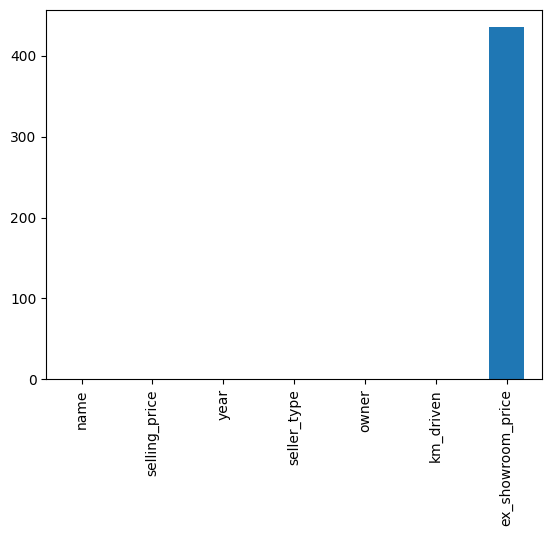

In [ ]:
df.isnull().sum().plot(kind='bar')

In [ ]:
df.ex_showroom_price.dropna(inplace=True)

# 8.  What is the highest ex_showroom_price recorded, and for which bike

In [ ]:
df.groupby('name')['ex_showroom_price'].max().sort_values(ascending=False).head(1)

,ex_showroom_price
name,
Harley-Davidson Street Bob,1278000.0


# 9. What is the total number of bikes listed by each seller typ

In [ ]:
df.groupby('seller_type')['name'].count()

,name
seller_type,
Dealer,6
Individual,1055


# 10.  What is the relationship between selling_price and km_driven for first-owner bikes

<Axes: xlabel='km_driven', ylabel='selling_price'>

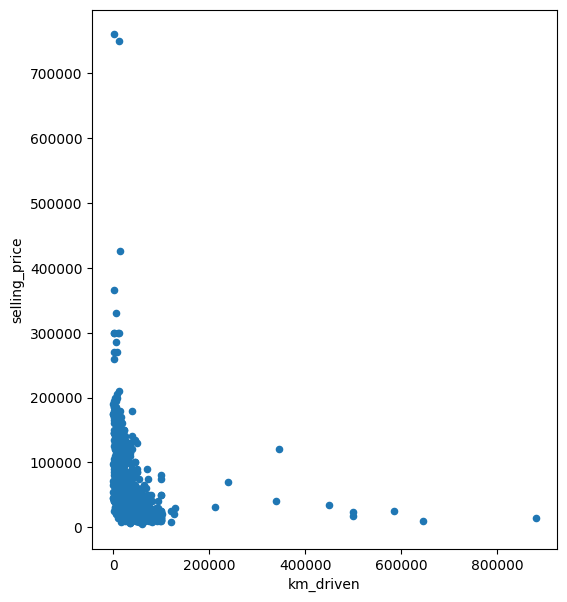

In [ ]:
df.plot(kind='scatter',x='km_driven',y='selling_price',figsize=(6,7))

# 11. Identify and remove outliers in the km_driven column using the IQR method

In [ ]:
q1= df.km_driven.quantile(0.25)
q3= df.km_driven.quantile(0.75)
iqr=q3-q1
lower_bound=q1-(1.5*iqr)
upper_bound=q3+(1.5*iqr)

In [ ]:
filtered_df = df[df.km_driven.between(lower_bound,upper_bound)]
filtered_df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1054,Hero CBZ Xtreme,20000,2010,Individual,1st owner,50000,78700.0
1055,Bajaj ct 100,18000,2017,Individual,1st owner,35000,32000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0


# 12.  Perform a bivariate analysis to visualize the relationship between year and selling_price

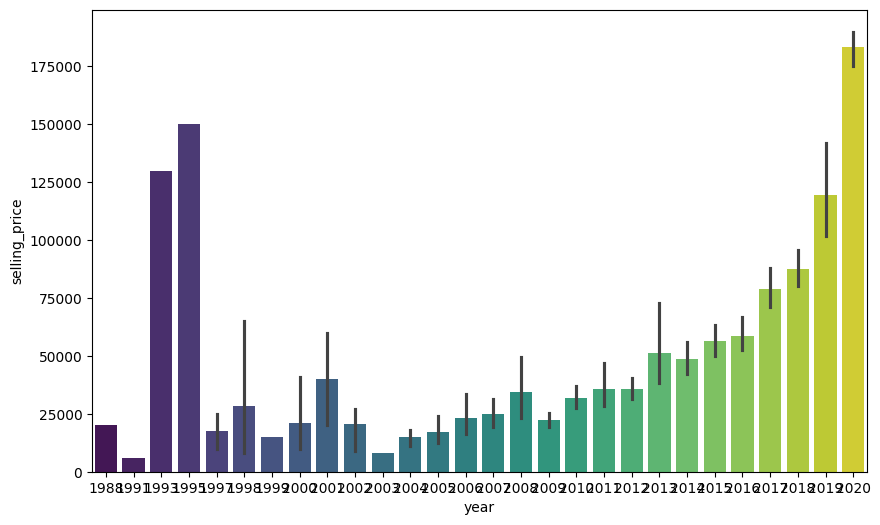

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='year',y='selling_price',data=df,palette='viridis')
plt.xlabel('year')
plt.ylabel('selling_price')
plt.show()

# 13.  What is the average depreciation in selling price based on the bike's age (current year - manufacturing year)

In [ ]:
df['bike_age'] = 2024 - df['year']
df['depreciation'] = df['selling_price'] - df['ex_showroom_price']
avg = df.groupby('bike_age')['depreciation'].mean()
avg

,depreciation
bike_age,
4,34260.000000
5,-2954.562500
6,-13023.194805
7,-22306.082353
8,-28328.190476
9,-28013.275000
10,-34505.606061
11,-43086.886792
12,-37317.648649


# 14. Which bike names are priced significantly above the average price for their manufacturing year

In [ ]:
df.groupby('year')['selling_price']

# 15. Develop a correlation matrix for numeric columns and visualize it using aheatmap

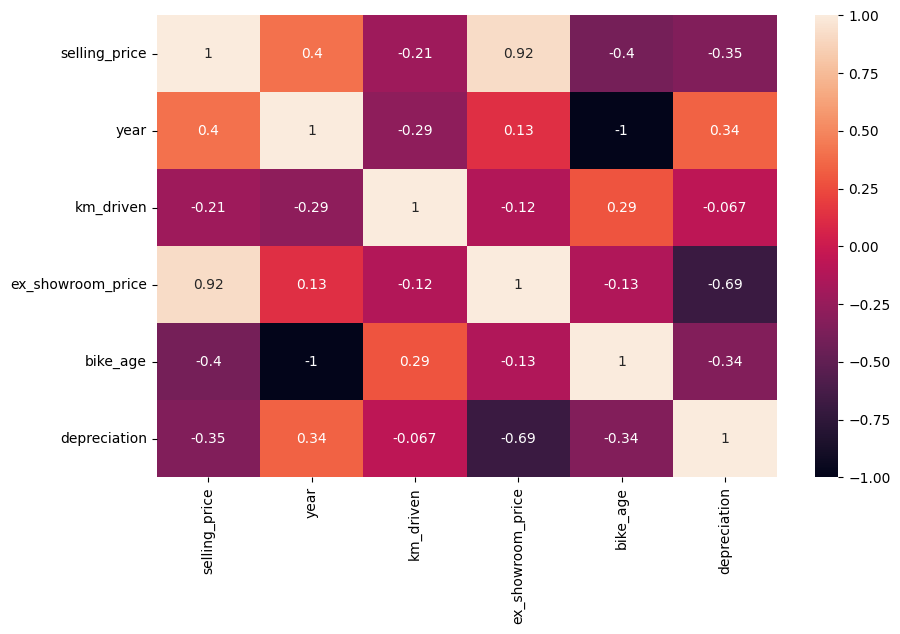

In [ ]:
numeric = df.select_dtypes(include=['float64', 'int64'])
numeric

plt.figure(figsize=(10,6))
sns.heatmap(numeric.corr(),annot=True)
plt.show()

# EDA-----------------2

In [4]:
df1 = pd.read_csv('Car Sale.csv')
df1.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000.0,06457-3834,SUV,8264678.0,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000.0,60504-7114,SUV,6848189.0,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500.0,38701-8047,Passenger,7298798.0,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000.0,99301-3882,SUV,6257557.0,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500.0,53546-9427,Hatchback,7081483.0,Janesville



# 1.What is the average selling price of cars for each dealer, and how does it compare across different dealers

In [ ]:
df1.groupby('Dealer_Name')['Price ($)'].mean()

,Price ($)
Dealer_Name,
Buddy Storbeck's Diesel Service Inc,27217.261563
C & M Motors Inc,28111.755200
Capitol KIA,28189.703822
Chrysler Plymouth,27555.526400
Chrysler of Tri-Cities,28123.091054
Classic Chevy,28602.014446
Clay Johnson Auto Sales,27816.027113
Diehl Motor CO Inc,27993.929487
Enterprise Rent A Car,28312.580800


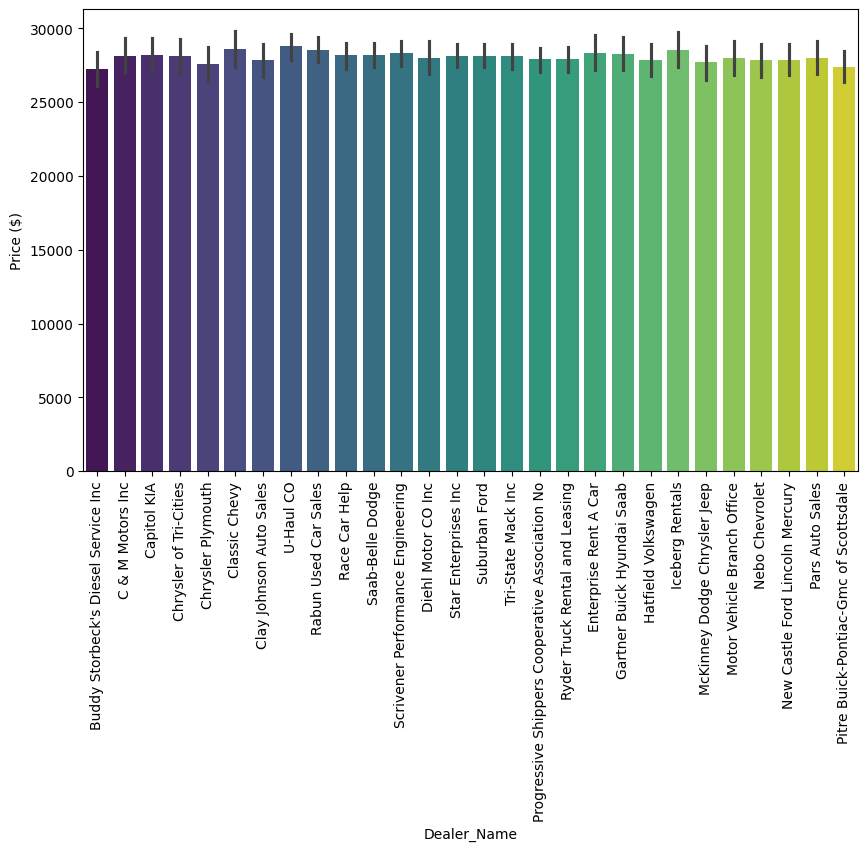

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Dealer_Name',y='Price ($)',data=df1,palette='viridis')
plt.xlabel('Dealer_Name')
plt.ylabel('Price ($)')
plt.xticks(rotation=90)
plt.show()

##2. Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends

In [ ]:
var = df1.groupby('Company')['Price ($)'].var().sort_values(ascending=False).head(1)
var

,Price ($)
Company,
Lincoln,3.864389e+08


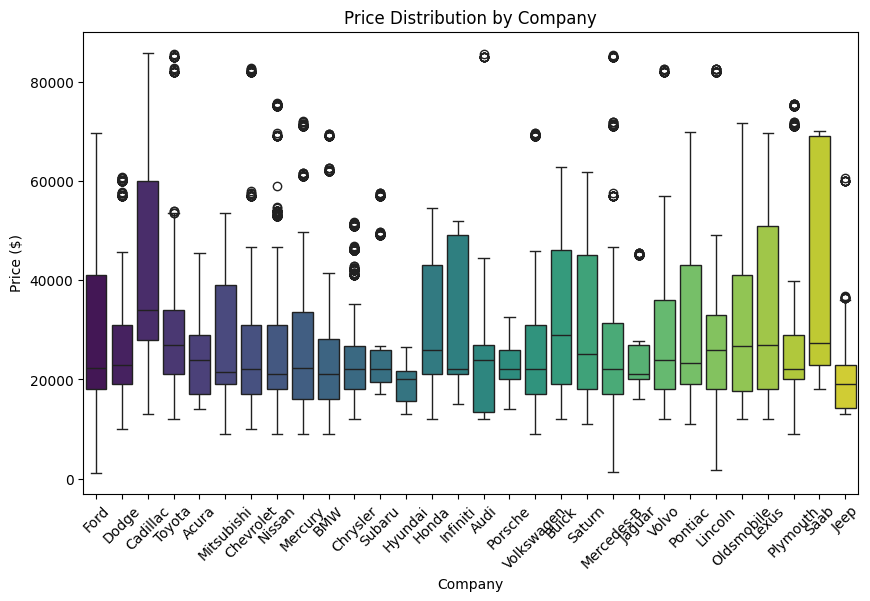

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Company', y='Price ($)', data=df1, palette='viridis')
plt.title('Price Distribution by Company')
plt.xticks(rotation=45)
plt.show()

## 3.What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare

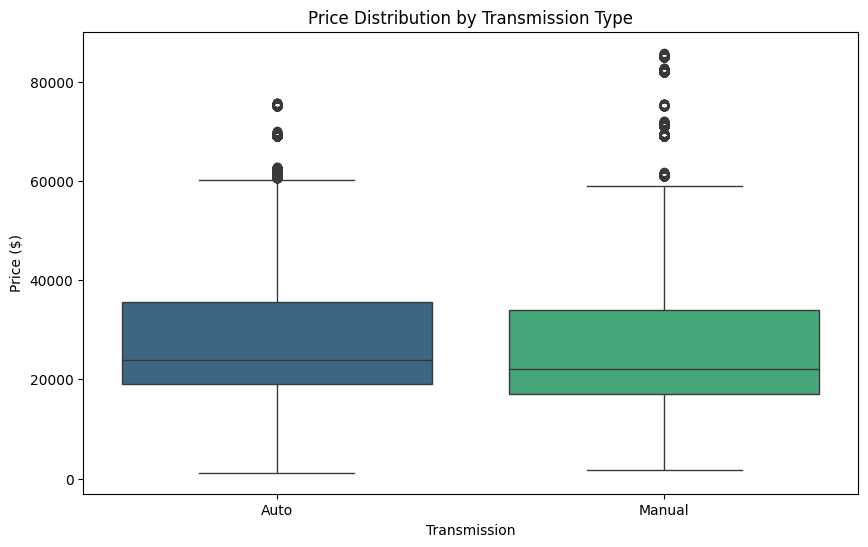

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Transmission', y='Price ($)', data=df1, palette='viridis')
plt.title('Price Distribution by Transmission Type')
plt.show()

In [ ]:
iqr_values = df1.groupby('Transmission')['Price ($)'].describe().loc[:, ['25%', '75%']]
iqr_values['IQR'] = iqr_values['75%'] - iqr_values['25%']

print(iqr_values)

                  25%      75%      IQR
Transmission                           
Auto          19000.0  35500.0  16500.0
Manual        17000.0  34000.0  17000.0


## 4.What is the distribution of car prices across different regions

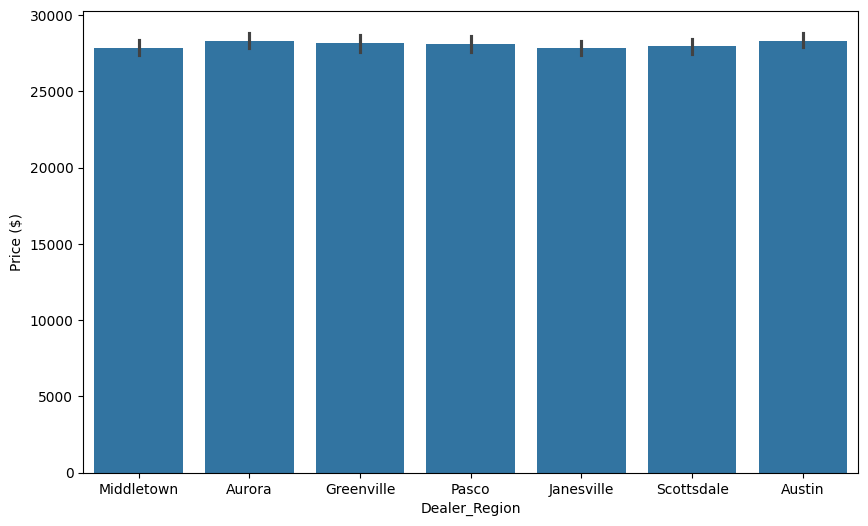

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Dealer_Region',y='Price ($)',data=df1)
plt.show()

## 5. What is the distribution of cars based on body styles

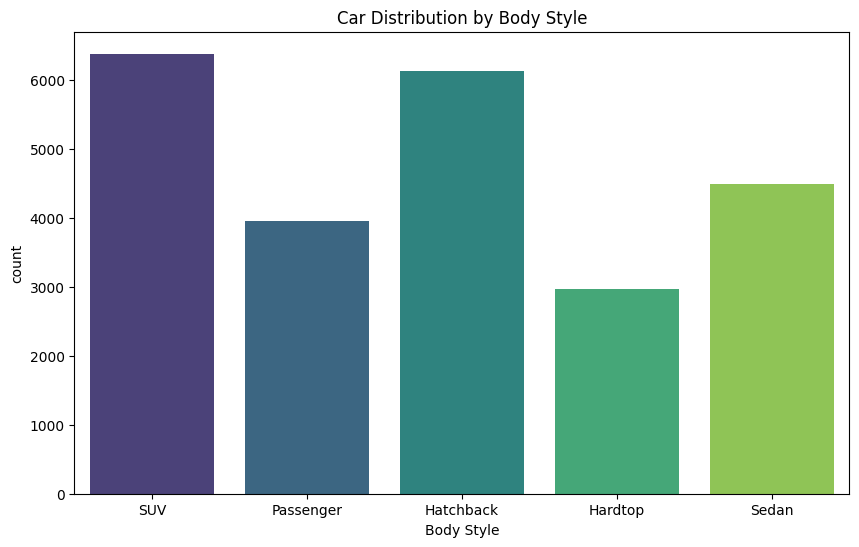

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Body Style', data=df1, palette='viridis')
plt.title('Car Distribution by Body Style')
plt.show()

##6. How does the average selling price of cars vary by customer gender and annual income

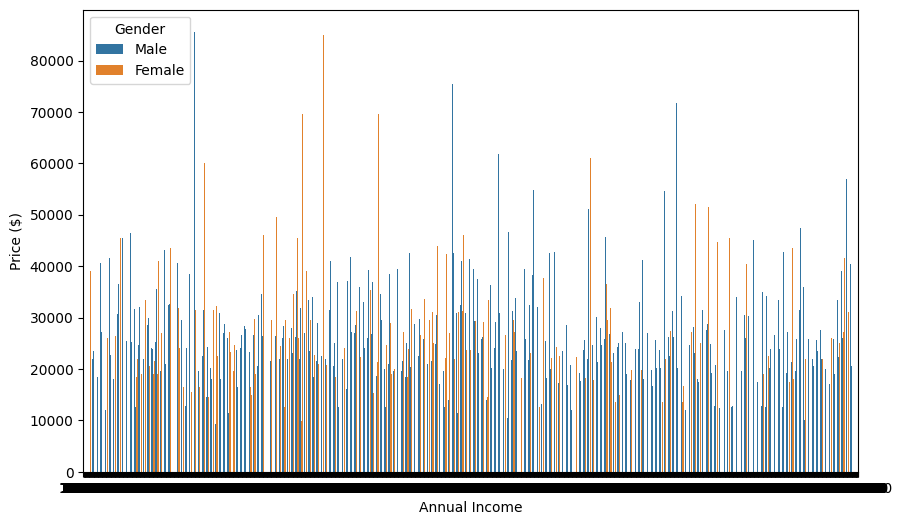

In [ ]:
avg_price_by_gender_income = df1.groupby(['Gender','Annual Income'])['Price ($)'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x='Annual Income',y='Price ($)',hue='Gender',data=avg_price_by_gender_income)
plt.show()

## 7. What is the distribution of car prices by region, and how does the number of cars sold vary by region

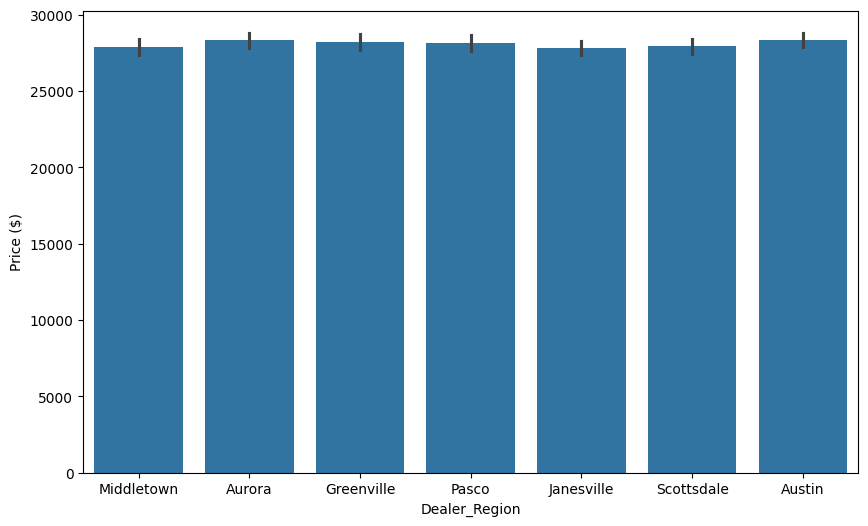

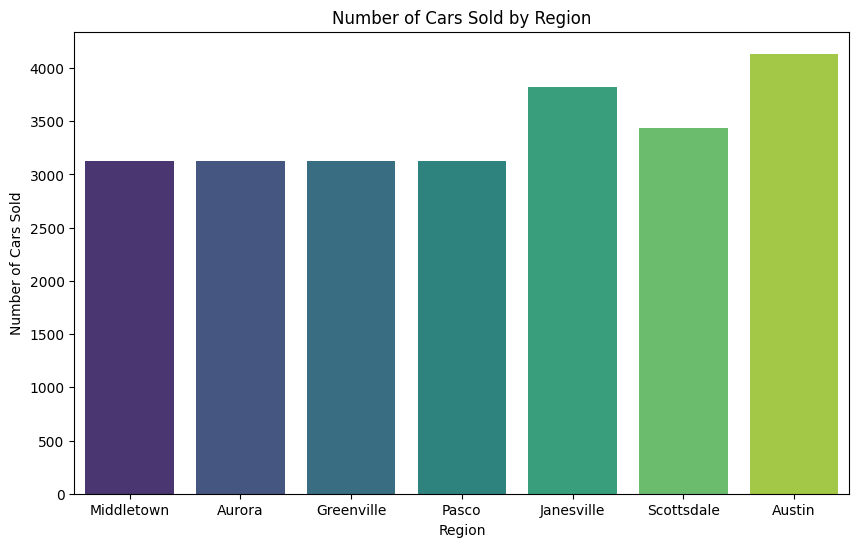

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Dealer_Region',y='Price ($)',data=df1)
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='Dealer_Region', data=df1, palette='viridis')
plt.title('Number of Cars Sold by Region')
plt.xlabel('Region')
plt.ylabel('Number of Cars Sold')
plt.show()

## 8.  How does the average car price differ between cars with different engine sizes

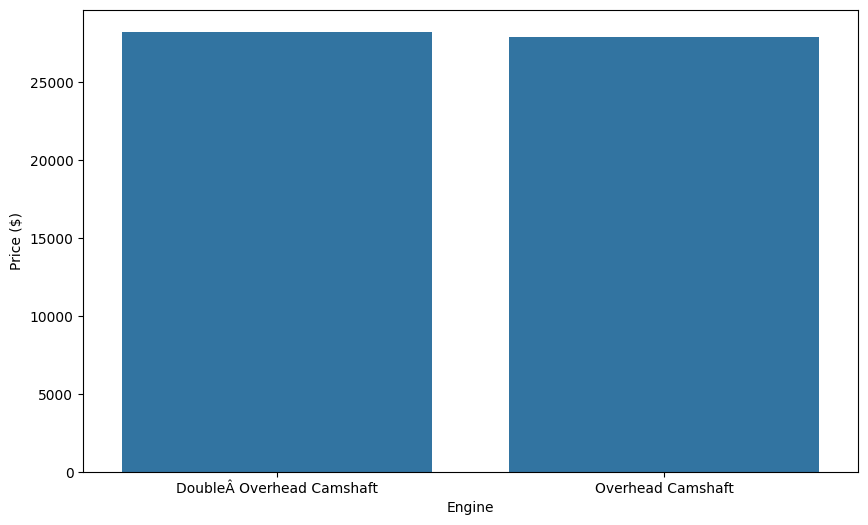

In [ ]:
avg = df1.groupby('Engine')['Price ($)'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='Engine',y='Price ($)',data=avg)
plt.show()


## 9.  How do car prices vary based on the customer’s annual income bracket

In [ ]:
#df1['Income_Bracket'] = pd.cut(df1['Annual Income'], bins=[0, 50000, 100000, 150000],
                   #           labels=['Low', 'Medium', 'High', 'Very High'])

# Calculate the average car price for each income bracket
avg_price = df.groupby('Income_Bracket')['Price ($)'].mean().reset_index()

# Plot the average car price by income bracket
sns.barplot(x='Income_Bracket', y='Price ($)', data=avg_price, palette='viridis')
plt.title('Average Car Price by Income Bracket')
plt.xlabel('Income Bracket')
plt.ylabel('Average Price ($)')
plt.show()

## 10. What are the top 5 car models with the highest number of sales, and how does their price distribution look

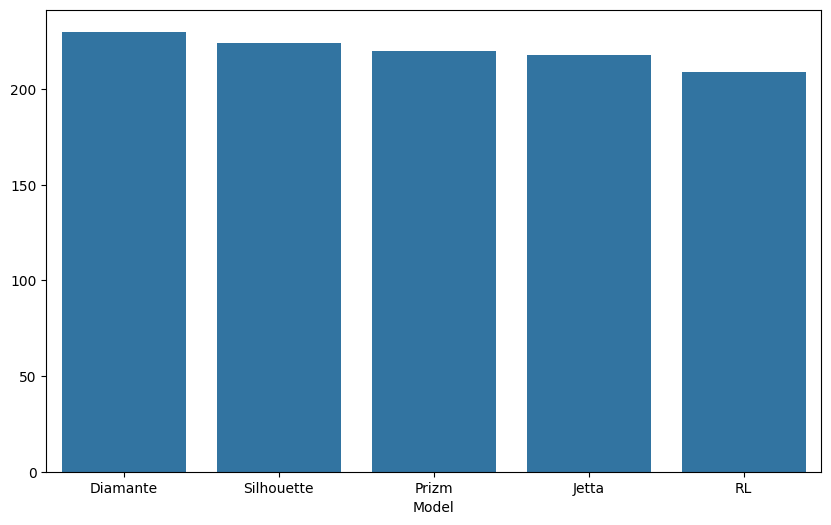

In [12]:
top = df1.Model.value_counts().head(5).sort_values(ascending=False)
top

plt.figure(figsize=(10,6))
sns.barplot(x=top.index,y=top.values)
plt.show()

## 11. How does car price vary with engine size across different car colors, and which colors have the highest price variation

In [19]:
df1.groupby('Color')['Price ($)'].var().sort_values(ascending=False)

,Price ($)
Color,
Red,2.475628e+08
Black,2.341751e+08
Pale White,1.917366e+08


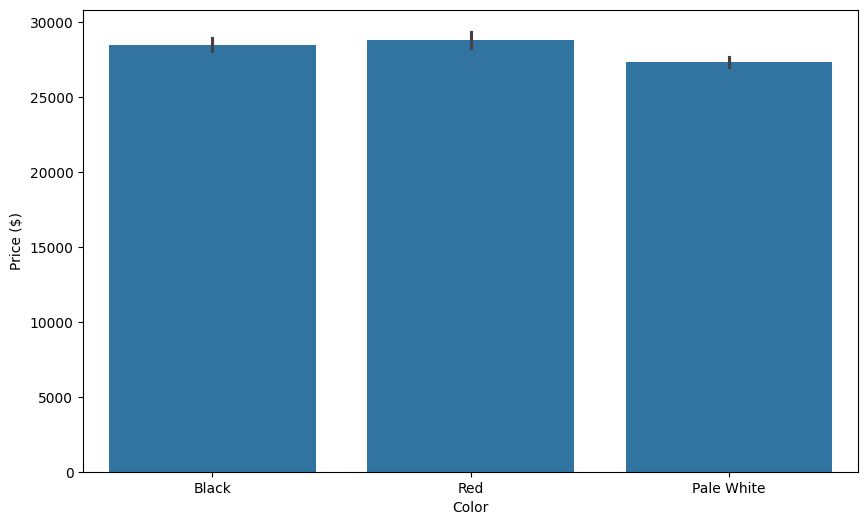

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(x='Color',y='Price ($)',data=df1)
plt.show()

## 12.  Is there any seasonal trend in car sales based on the date of sale

Season
Fall      3930
Spring    3809
Summer    2200
Winter    3150
dtype: int64


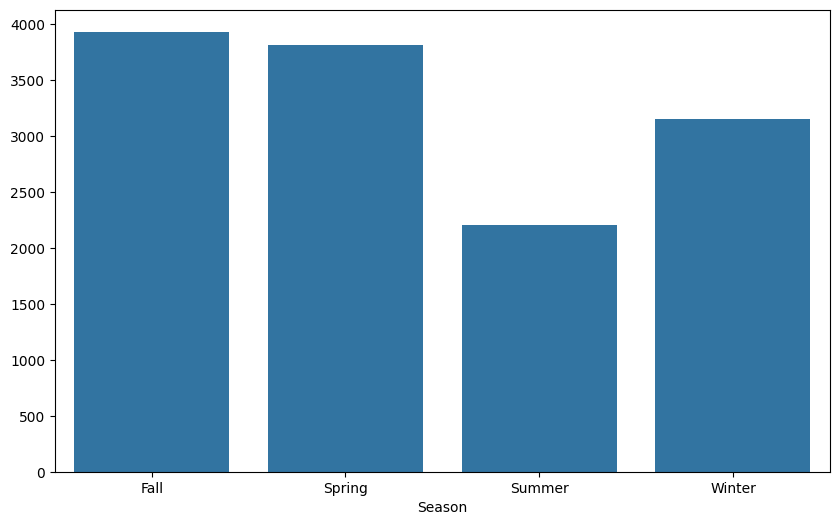

In [23]:
df1['Date']=pd.to_datetime(df1['Date'])
df1['Month']=df1['Date'].dt.month
df1['Season']=df1['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

seasonal_sales=df1.groupby('Season').size()
print(seasonal_sales)

plt.figure(figsize=(10,6))
sns.barplot(x=seasonal_sales.index,y=seasonal_sales.values)
plt.show()

## 13. How does the car price distribution change when considering different combinations of body style and transmission typ

Body Style  Transmission
Hardtop     Auto             702
            Manual           795
Hatchback   Auto            2064
            Manual          1614
Passenger   Auto            1125
            Manual          1028
SUV         Auto            1600
            Manual          1699
Sedan       Auto            1429
            Manual          1032
Name: Price ($), dtype: int64


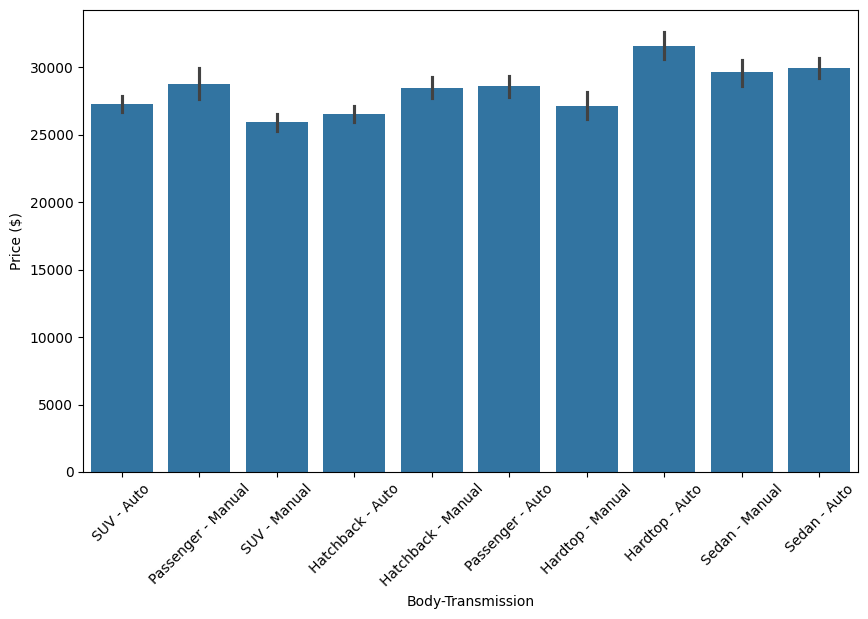

In [35]:
price_distribution = df1.groupby(['Body Style','Transmission'])['Price ($)'].size()
print(price_distribution)
df1['Body-Transmission'] = df1['Body Style'] + " - " + df1['Transmission']

plt.figure(figsize=(10,6))
sns.barplot(x='Body-Transmission',y='Price ($)',data=df1)
plt.xticks(rotation=45)
plt.show()

## 14.  What is the correlation between car price, engine size, and annual income of customers, and how do these features interact

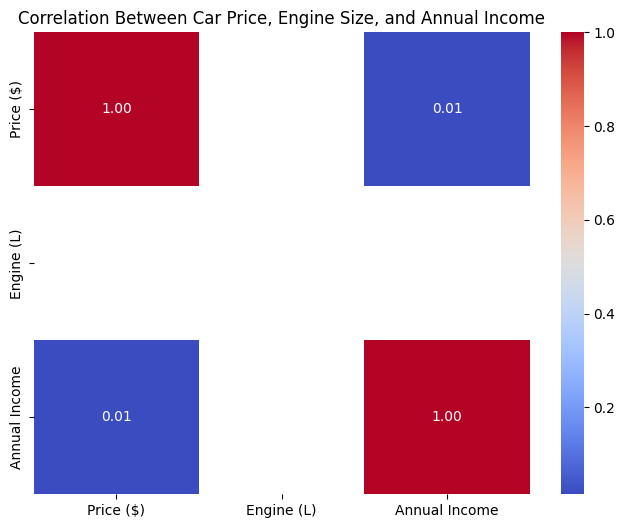

In [44]:
engine_mapping = {'I4': 2.0, 'V6': 3.0, 'V8': 4.0}  # Example mapping
df1['Engine (L)'] = df1['Engine'].map(engine_mapping)

data = df1[['Price ($)','Engine (L)','Annual Income']]
correlation = data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Between Car Price, Engine Size, and Annual Income')
plt.show()

## 15. How does the average car price vary across different car models and engine types

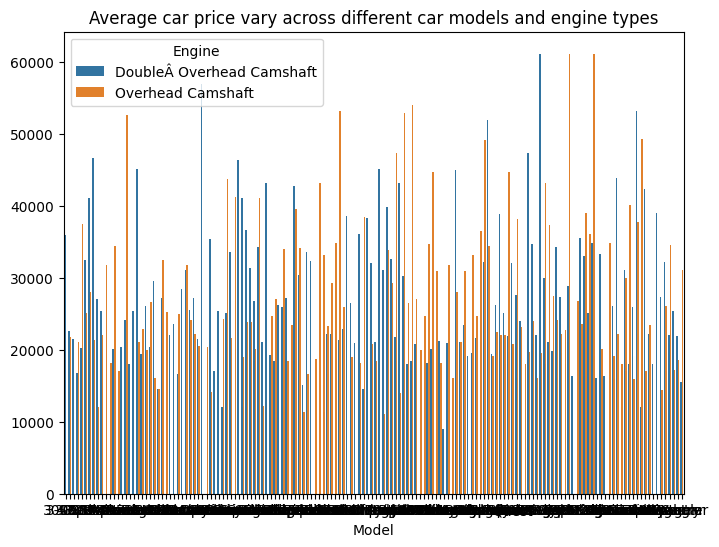

In [48]:
d1 = df1.groupby(['Model','Engine'])['Price ($)'].mean()
plt.figure(figsize=(8, 6))
sns.barplot(x=d1.index.get_level_values(0), y=d1.values, hue=d1.index.get_level_values(1))
plt.title('Average car price vary across different car models and engine types')
plt.show()

# EDA_______4

## 1. Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful bold text

In [2]:
df2=pd.read_csv('spotify.csv')
df2.head()

,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe


In [3]:
df2.isnull().sum()

,0
Artist,0
Track Name,0
Popularity,0
Duration (ms),0
Track ID,0


In [4]:
df2.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
435,True
436,False
437,False
438,False


In [5]:
df2.drop_duplicates(inplace=True)

In [6]:
df2.duplicated().sum()

0

## 2. What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram

Text(0.5, 1.0, 'Distribution of Popularity')

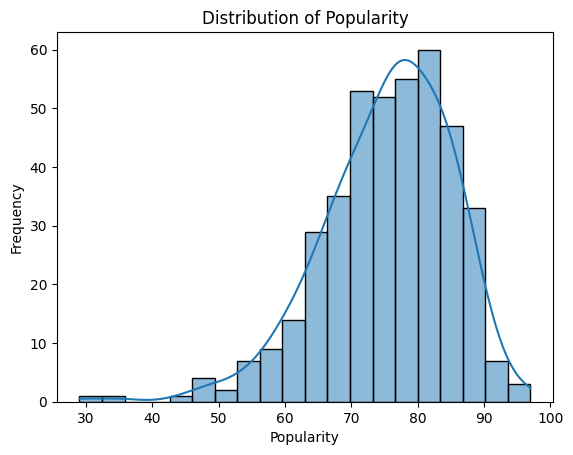

In [63]:
df2.groupby('Track Name')['Popularity'].count()

sns.histplot(df2['Popularity'], bins=20, kde=True)
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.title('Distribution of Popularity')

## 3.  Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot

<Axes: xlabel='Popularity', ylabel='Duration (ms)'>

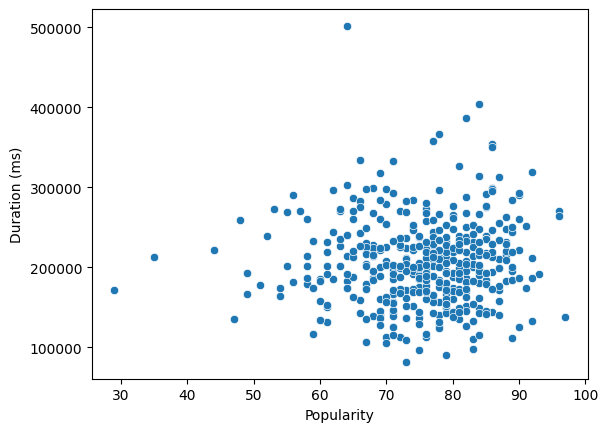

In [66]:
sns.scatterplot(x='Popularity',y='Duration (ms)',data=df2)

## 4.  Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot

In [84]:
d2 = df2.Artist.value_counts().head(1)
d2

,count
Artist,
Drake,17


Artist
Drake             17
Eminem            11
Flo Rida          10
Ludacris          10
Timbaland         10
                  ..
Arizona Zervas     1
Fivio Foreign      1
Pressa             1
David Guetta       1
Diddy              1
Name: count, Length: 115, dtype: int64


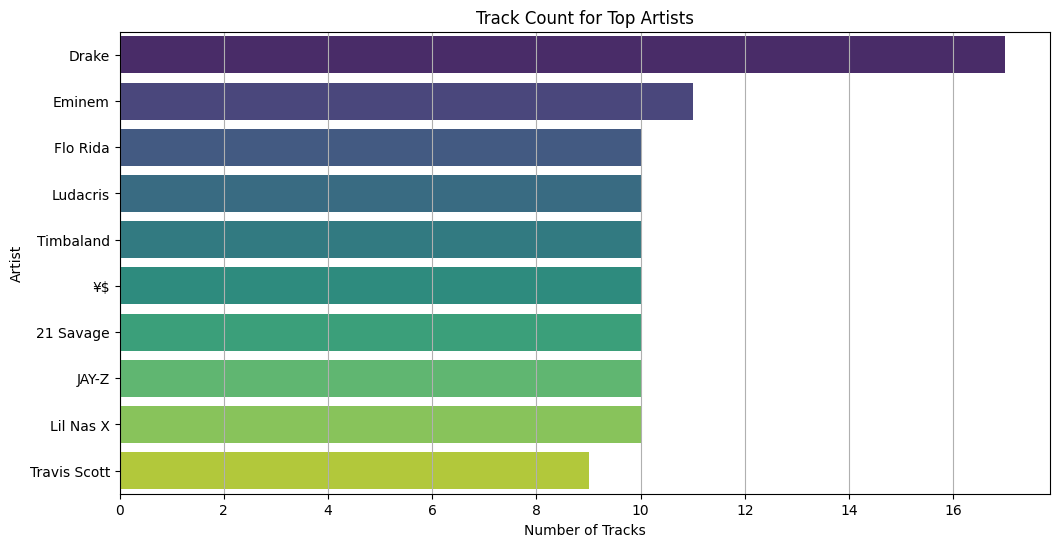

In [86]:
track_counts = df2['Artist'].value_counts()
top_count = track_counts.max()
print(track_counts)

plt.figure(figsize=(12, 6))
sns.countplot(y='Artist', data=df2, order=track_counts.index[:10], palette='viridis')
plt.title('Track Count for Top Artists')
plt.xlabel('Number of Tracks')
plt.ylabel('Artist')
plt.grid(axis='x')
plt.show()

## 5. What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each

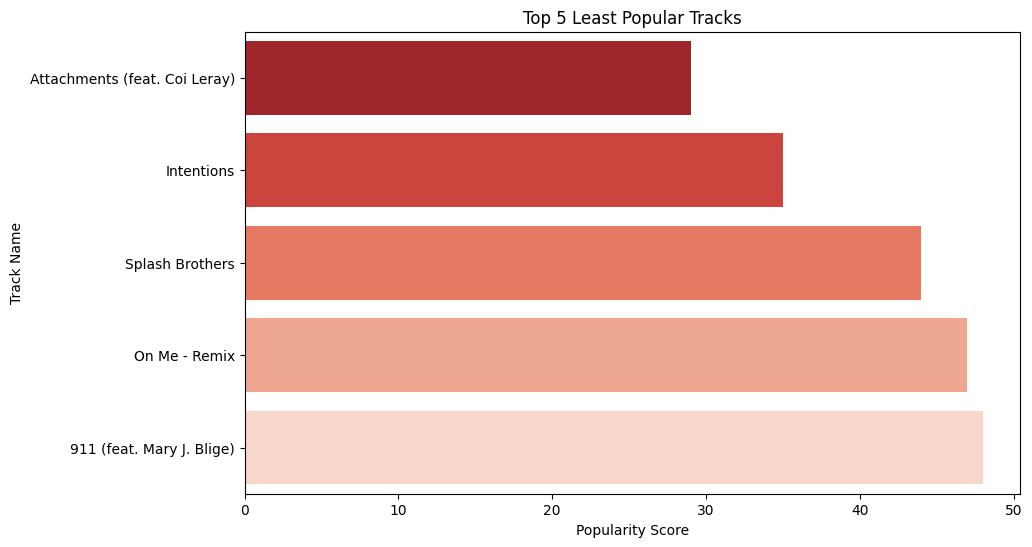

In [8]:
least_popular_tracks = df2[['Track Name', 'Artist', 'Popularity']].sort_values(by='Popularity', ascending=True).head(5)


plt.figure(figsize=(10, 6))
sns.barplot(x='Popularity', y='Track Name', data=least_popular_tracks, palette='Reds_r')
plt.title('Top 5 Least Popular Tracks')
plt.xlabel('Popularity Score')
plt.ylabel('Track Name')
plt.show()

## 6. Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and display the average popularity for each artist

In [21]:
top5 = df2.Artist.value_counts().head(5)

avg = df2.groupby('Artist')['Popularity'].mean().sort_values(ascending=False)
avg

,Popularity
Artist,
cassö,92.000000
Trueno,89.000000
David Guetta,87.000000
Travis Scott,86.555556
¥$,85.100000
...,...
RAYE,55.000000
Wyclef Jean,54.500000
Arizona Zervas,54.000000


## 7.  For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist

In [30]:
top_artists = df2.groupby('Artist')['Popularity'].mean().sort_values(ascending=False).head(5)
filtered_df = df2[df2['Artist'].isin(top_artists.index)]
most_popular_tracks = filtered_df.loc[filtered_df.groupby('Artist')['Popularity'].idxmax()]
print(most_popular_tracks[['Artist', 'Track Name', 'Popularity']])

           Artist                    Track Name  Popularity
200  David Guetta            Baby Don't Hurt Me          87
30   Travis Scott    FE!N (feat. Playboi Carti)          93
241        Trueno  Mamichula - con Nicki Nicole          89
140         cassö                         Prada          92
260            ¥$                      CARNIVAL          96


## 8.  Visualize relationships between multiple numerical variables simultaneously using a pair plot

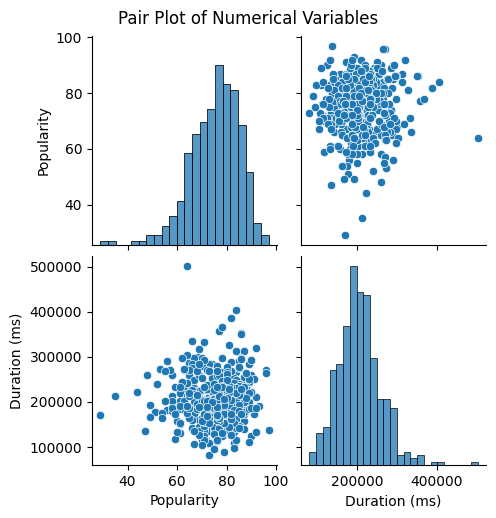

In [38]:
numerical_cols = df2.select_dtypes(include=['float64','int64'])

sns.pairplot(numerical_cols)
plt.suptitle("Pair Plot of Numerical Variables", y=1.02)
plt.show()

## 9. Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot

In [52]:
dur = df2.groupby('Artist')['Duration (ms)'].mean()


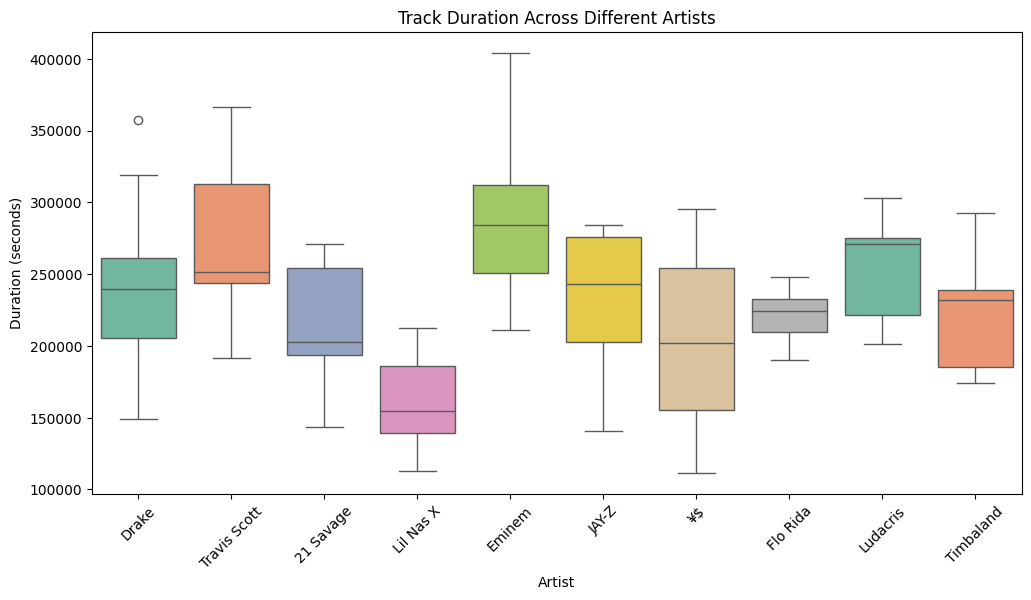

In [59]:
top_artists = df2['Artist'].value_counts().head(10).index
filtered_df = df2[df2['Artist'].isin(top_artists)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Artist', y='Duration (ms)', data=filtered_df, palette='Set2')
plt.xticks(rotation=45)
plt.title('Track Duration Across Different Artists')
plt.xlabel('Artist')
plt.ylabel('Duration (seconds)')
plt.show()

## 10. How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot.

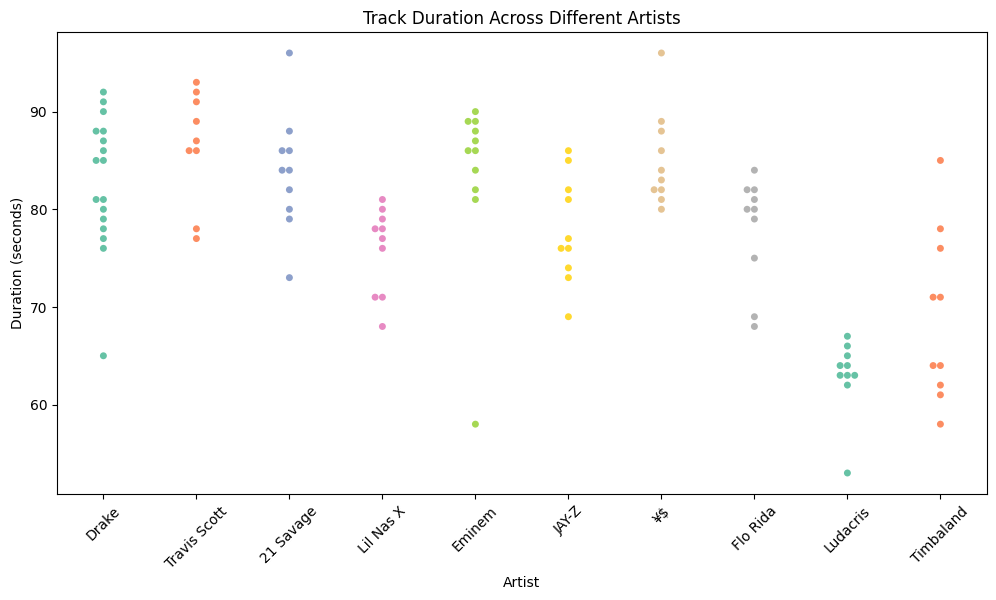

In [60]:
top_artists = df2['Artist'].value_counts().head(10).index
filtered_df = df2[df2['Artist'].isin(top_artists)]

plt.figure(figsize=(12, 6))
sns.swarmplot(x='Artist', y='Popularity', data=filtered_df, palette='Set2')
plt.xticks(rotation=45)
plt.title('Track Duration Across Different Artists')
plt.xlabel('Artist')
plt.ylabel('Duration (seconds)')
plt.show()